# Dtypes, PM plots and exposure

This example demonstrates how to:

- Load size-resolved ELPI data (`Aerosol2D`)
- Inspect dtype, units, and particle density
- Convert between different distribution types via `dtype_converter`
- Compute cumulative Pₓ (e.g. PM₂.₅, PM₄.₂) with `PM_calc`
- Plot PMₓ time series with `plot_pm_timeseries`
- Adjust assumed particle density with `set_density`
- Use `summarize_activities` and `summarize_exposure` for PM-based metrics

In [ ]:
import matplotlib.pyplot as plt
import aerosoltools as at

## Load ELPI sample data

Initially load an ELPI test dataset.

In [4]:
filename = r"..\..\tests\data\Sample_ELPI.txt"
elpi = at.Load_ELPI_file(filename)

################# Warning! #################
          Density ≠ 1.0 assumed           
  Bin edges estimated via geometric means 
###########################################


A warning is given, seeing that the density in the given raw data is not set equal to 1.0. The density of the raw data is read, loaded and stored within the generated elpi variable, but the user is still alerted.

## Check dtype, unit, and density

The loader sets the initial distribution type (e.g. `dN`) and unit.
Assumed particle density is stored in `elpi.density` (g/cm³).

In [5]:
print("Initial dtype:", elpi.dtype)
print("Initial unit:", elpi.unit)
print("Initial density (g/cm³):", elpi.density)

Initial dtype: dN
Initial unit: cm⁻³
Initial density (g/cm³): 0.14


## Change density and convert to mass distribution

We can update the assumed particle density with `set_density()` and then
convert to a mass-based size distribution using `dtype_converter("dM")`.

In [7]:
# For illustration, set density to 1.5 g/cm³
elpi.set_density(1.5)
elpi.dtype_converter("dM")
print("Updated dtype:", elpi.dtype)
print("Updated density (g/cm³):", elpi.density)
print("Updated unit:", elpi.unit)

Updated dtype: dM
Updated density (g/cm³): 1.5
Updated unit: ug/m³


## Compute PM fractions with `PM_calc`

We now calculate mass-based Pₓ metrics such as PM₂.₅ and PM₄.₂.
The results are stored in `elpi.extra_data` as additional columns.

In [8]:
# Compute cumulative PM2.5 and PM4.2 (µm cut points)
elpi.PM_calc(dtype="dM", PM=2.5)
elpi.PM_calc(dtype="dM", PM=4.2)
print([c for c in elpi.extra_data.columns if c.startswith("PM")])


['PM2.5', 'PM4.2']


## Plot PM time series

Use `plot_pm_timeseries` to visualize the evolution of PMₓ over time.

(<Figure size 1900x1000 with 1 Axes>, <Axes: ylabel='PM, ug/m³'>)

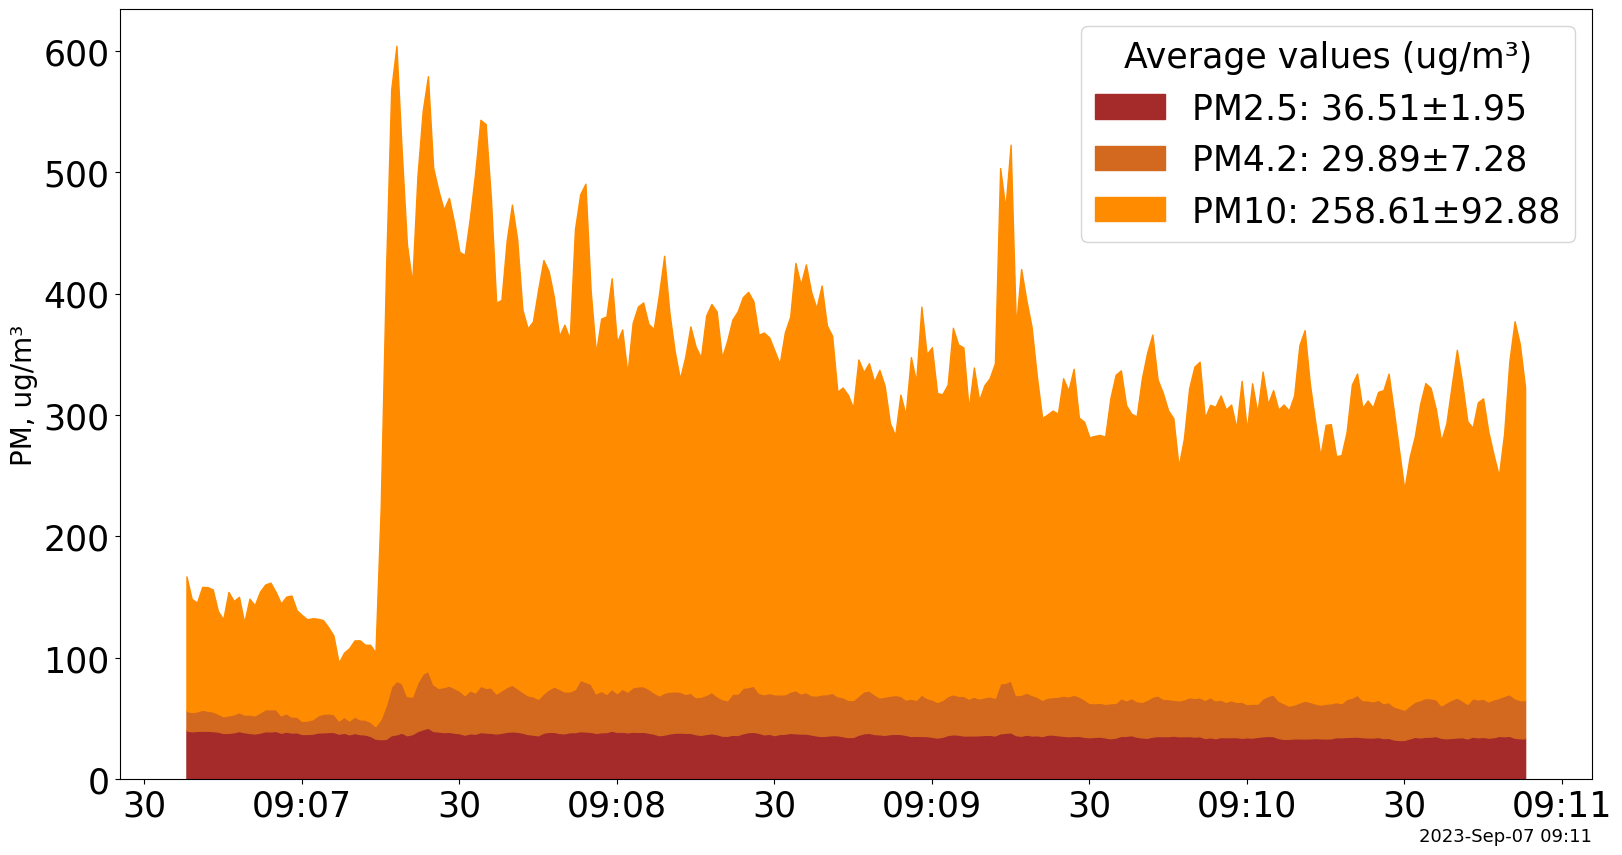

In [12]:
elpi.plot_PM_timeseries(PM_values=[2.5, 4.2, 10])

## Define activities and summarize

As with `Aerosol1D`, we can mark time segments and compute activity-based
statistics using `summarize_activities()`.

In [13]:
activity_periods = {
    "Background": [("2023/09/07 09:06:50", "2023/09/07 09:07:50")],
    "Emission":   [("2023/09/07 09:07:55", "2023/09/07 09:08:30")],
    "Decay":      [("2023/09/07 09:09:00", "2023/09/07 09:10:50")],
}
elpi.mark_activities(activity_periods)
summary = elpi.summarize_activities()
summary


Summary of aerosol properties (transposed):

+------------------------+----------+------------+----------+---------+
|                        | All data | Background | Emission |  Decay  |
+------------------------+----------+------------+----------+---------+
|    Duration (HH:MM)    |  00:04   |   00:01    |  00:00   |  00:01  |
|       PNC [cm⁻³]       |  197.44  |   222.84   |  203.63  | 179.39  |
|     PNC [cm⁻³] std     |   48.9   |   61.26    |  42.67   |  39.3   |
|      PM1 [µg/m³]       |  13.79   |   14.97    |  14.06   |  12.85  |
|    PM1 [µg/m³] std     |   1.15   |    0.89    |   0.26   |  0.38   |
|     PM2.5 [µg/m³]      |  36.51   |   37.94    |  37.83   |  34.95  |
|   PM2.5 [µg/m³] std    |   1.95   |    1.6     |   1.09   |  1.13   |
|      PM4 [µg/m³]       |  61.78   |   60.51    |  66.44   |  61.04  |
|    PM4 [µg/m³] std     |   6.28   |   10.08    |   2.77   |  3.12   |
|      PM10 [µg/m³]      |  325.0   |   320.29   |  374.75  | 318.69  |
|    PM10 [µg/m³] 

,Segment,Duration (HH:MM),PNC [cm⁻³],PNC [cm⁻³] std,PM1 [µg/m³],PM1 [µg/m³] std,PM2.5 [µg/m³],PM2.5 [µg/m³] std,PM4 [µg/m³],PM4 [µg/m³] std,PM10 [µg/m³],PM10 [µg/m³] std,Total Mass [µg/m³],Total Mass [µg/m³] std,Mode Dp [nm],Mode Dp [nm] std,Median Dp [nm],Median Dp [nm] std,GMD [nm],GMD [nm] std
0,All data,00:04,197.44,48.90,13.79,1.15,36.51,1.95,61.78,6.28,325.00,99.82,1335.13,549.75,125.2,131.1,224.2,68.6,203.3,79.5
1,Background,00:01,222.84,61.26,14.97,0.89,37.94,1.60,60.51,10.08,320.29,169.28,1421.95,896.41,113.6,125.6,210.6,76.9,193.0,79.2
2,Emission,00:00,203.63,42.67,14.06,0.26,37.83,1.09,66.44,2.77,374.75,22.18,1615.86,216.46,125.4,128.9,226.2,66.2,201.4,77.8
3,Decay,00:01,179.39,39.30,12.85,0.38,34.95,1.13,61.04,3.12,318.69,42.50,1225.18,248.88,132.9,135.4,228.1,67.3,212.6,84.1


## Exposure summary for respirable dust (PM4.2)

Finally, we use `summarize_exposure` on the `Aerosol2D` object
to obtain exposure metrics for PM₄.₂ during the *Emission* task,
using *Background* as the background activity.

In [15]:
exp = elpi.summarize_exposure(
    metric="PM4.2",
    activity="Emission",
    background="Background",  # use mean Background as background level
    exposure_hours=None,       # assume exposure equals task duration
    short_limit=1.0,
    long_limit=1.0,
    short_window="15min",
    twa_window="8h",
)
exp


Exposure summary for segment 'Emission' and metric 'PM4.2' (µg/m³):

+--------------------------------------------+----------+
|                   Metric                   | Emission |
+--------------------------------------------+----------+
|                   Metric                   |  PM4.2   |
|                    Unit                    |  µg/m³   |
|                Duration_min                |   0.6    |
|               Duration_HH:MM               |  00:00   |
|                    Mean                    |  71.797  |
|                    Std                     |  3.127   |
|                   Median                   |  71.21   |
|                    Max                     |  78.57   |
|                  Seg_TWA                   |  71.797  |
|                 Window_TWA                 |  64.657  |
|             Window_TWA_window              |    8h    |
|                Short_limit                 |   1.0    |
|                Short_window                |  15min   |
| 

,Segment,Metric,Unit,Duration_min,Duration_HH:MM,Mean,Std,Median,Max,Seg_TWA,...,Short_limit_exceedance_fraction,Short_limit_fullwindow_exceedance_min,Short_limit_fullwindow_exceedance_episodes,Long_limit,Long_limit_exceeded,Long_limit_exceedance_min,C95,C99,IQR,Peaks
0,Emission,PM4.2,µg/m³,0.6,00:00,71.797,3.127,71.21,78.57,71.797,...,1.0,0.02,1,1.0,True,0.6,76.709,78.018,4.235,0
